# **ACQUISITION TEST**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys

!pip install facenet-pytorch

cfg_path = "/content/drive/MyDrive/11/Consegna finale/src"

if cfg_path not in sys.path:
    sys.path.append(cfg_path)

import cv2
import numpy as np
from base64 import b64decode
from IPython.display import display, Javascript
from google.colab.output import eval_js
from google.colab.patches import cv2_imshow
from acquisition import BiometricAcquisition

## **Acquisizione Immagini da Webcam**

Poiché Google Colab viene eseguito su un server remoto, non può accedere direttamente alla periferica video locale. Questa sezione implementa un **bridge JavaScript-Python**:

1.  **Interfaccia Web:** Inietta codice JavaScript nel browser per attivare la webcam e mostrare un pulsante "Cattura Foto".
2.  **Trasmissione Dati:** L'immagine catturata viene convertita in una stringa **Base64** e inviata dal browser al kernel Python.
3.  **Decodifica:** Python riceve la stringa, la decodifica e la converte in un array NumPy compatibile con OpenCV.

In [ ]:
def _js_to_image(js_reply):
    if not js_reply or 'base64,' not in js_reply: return None
    try:
        image_bytes = b64decode(js_reply.split(',')[1])
        jpg_as_np = np.frombuffer(image_bytes, dtype=np.uint8)
        return cv2.imdecode(jpg_as_np, flags=1)
    except Exception: return None

def capture_image_colab(quality=0.8):
    """
    Questa è la funzione che passeremo alla classe.
    Non prende argomenti complessi, restituisce solo l'immagine o None.
    """
    js = Javascript('''
      async function takePhoto(quality) {
        const div = document.createElement('div');
        const capture = document.createElement('button');
        capture.textContent = 'Cattura Foto';
        div.appendChild(capture);
        const video = document.createElement('video');
        video.style.display = 'block';
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(div);
        div.appendChild(video);
        video.srcObject = stream;
        await video.play();
        google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);
        await new Promise((resolve) => capture.onclick = resolve);
        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);
        stream.getVideoTracks()[0].stop();
        div.remove();
        return canvas.toDataURL('image/jpeg', quality);
      }
      ''')
    display(js)
    try: return _js_to_image(eval_js('takePhoto({})'.format(quality)))
    except Exception: return None

## **Acquisizione Biometrica con Controllo Posa**

Questa fase esegue la cattura del volto applicando standard di qualità rigidi, simili a quelli usati nei sistemi di identificazione documenti (ICAO). Non basta che ci sia un volto; deve essere **frontale** e **nitido**.

Il sistema analizza in tempo reale:
1.  **Qualità Immagine:** Misura sfocatura (Laplacian Variance), contrasto e luminosità media.
2.  **Posa 3D (Yaw & Pitch):** Stima la rotazione della testa analizzando la geometria dei 5 landmarks facciali (occhi, naso, angoli bocca):
    * **Yaw (Rotazione Orizzontale):** Calcolato basandosi sulla simmetria delle distanze naso-bocca.
    * **Pitch (Inclinazione Verticale):** Calcolato valutando il rapporto tra la distanza occhi-naso e naso-bocca.



Se l'immagine supera i controlli, viene salvata come campione di riferimento (Enrollment). Altrimenti, il sistema ritenta o seleziona il "miglior candidato" disponibile.

[LIB] Detector inizializzato su cpu. Controllo Yaw + Pitch attivo.
Inizio procedura (Yaw Th: 0.3, Pitch Range: (0.35, 1.8))...

--- Tentativo 1/3 ---


<IPython.core.display.Javascript object>

Volto GIRATO(score 0.69): B=844, C=38
  -> RIFIUTATO: Testa girata orizzontalmente (0.69)

--- Tentativo 2/3 ---


<IPython.core.display.Javascript object>

Volto FRONTALE: B=1843, C=44
Qualità e Posa 3D accettate!
Visualizzazione risultato finale:


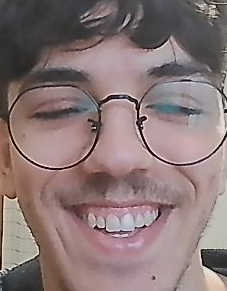

In [ ]:
acquisition = BiometricAcquisition(
    max_attempts=3,
    blur_threshold=80.0,
    min_face_size=350,
    symmetry_threshold=0.30,
    pitch_range=(0.35, 1.80)
)

face, timestamp = acquisition.acquire_best_sample(capture_function=capture_image_colab)

if face is not None:
    print("Visualizzazione risultato finale:")
    cv2_imshow(face)
else:
    print("Fallito.")

## **Test Empirico di Calibrazione Posa**

Questa sezione esegue una **diagnostica guidata** per verificare la robustezza dell'algoritmo di stima della posa. Serve a capire come il sistema reagisce ai movimenti della testa e a calibrare le soglie (`symmetry_threshold` e `pitch_range`).

**Procedura:**
Il sistema richiederà di assumere **5 pose specifiche** in sequenza:
1.  **Frontale:** (Baseline di riferimento).
2.  **Yaw (Rotazione Orizzontale):** Rotazione testa sinistra/destra.
3.  **Pitch (Inclinazione Verticale):** Sguardo in alto/basso.

**Visualizzazione:**
Al termine, verrà generata una griglia grafica che mostra:
* **Landmarks:** I punti chiave rilevati (occhi, naso, bocca) e le linee geometriche vettoriali usate per il calcolo.
* **Metriche:** I valori numerici di score e i flag di accettazione/rifiuto (Verde=Pass, Rosso=Fail).

In [ ]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import time

def run_empirical_test(acquisition_system, capture_func, samples_per_pose=2):
    """
    Esegue un test guidato per raccogliere metriche su diverse pose.
    Il parametro samples_per_pose (default=2) determina quante foto fare per ogni posa.
    """
    # Lista delle pose da testare
    test_sequence = [
        ("FRONTALE", "Guarda dritto in camera, espressione neutra"),
        ("ROTAZIONE_SX (Yaw)", "Gira leggermente il volto a sinistra"),
        ("ROTAZIONE_DX (Yaw)", "Gira leggermente il volto a destra"),
        ("SGUARDO_ALTO (Pitch)", "Alza il mento guardando verso l'alto"),
        ("SGUARDO_BASSO (Pitch)", "Abbassa il mento guardando verso il basso")
    ]

    results = []
    total_photos = len(test_sequence) * samples_per_pose

    print(f"=== INIZIO TEST EMPIRICO: {total_photos} ACQUISIZIONI TOTALI ===")
    print(f"Faremo {samples_per_pose} scatti per ognuna delle 5 pose.\n")

    for title, instruction in test_sequence:
        print(f"\n--------------------------------------------------")
        print(f" POSA RICHIESTA: {title}")
        print(f" ISTRUZIONE: {instruction}")
        print(f"--------------------------------------------------")

        for i in range(samples_per_pose):
            print(f"\n>>> Scatto {i+1} di {samples_per_pose} per [{title}]")
            print("Premi il pulsante 'Cattura Foto'...")

            # 1. Cattura immagine
            img = capture_func()

            if img is None:
                print("Acquisizione fallita o annullata.")
                # Aggiungiamo un placeholder vuoto per non rompere il plot
                results.append({'title': f"{title} #{i+1} (Fallito)", 'image': None, 'metrics': {}, 'landmarks': None, 'face_detected': False})
                continue

            # 2. Otteniamo i dati grezzi usando i metodi della classe
            face_roi, metrics, msg = acquisition_system._extract_and_score_face(img)

            # 3. Ricalcoliamo i landmark solo per il plotting
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            boxes, probs, points = acquisition_system.detector.detect(img_rgb, landmarks=True)

            landmarks = points[0] if points is not None else None

            # Salviamo i risultati con il numero progressivo
            results.append({
                'title': f"{title} (Scatto {i+1})",
                'image': img_rgb,
                'metrics': metrics,
                'landmarks': landmarks,
                'face_detected': face_roi is not None
            })

            print(f"   -> Acquisito. {msg}")
            time.sleep(1.5) # Pausa di sicurezza tra uno scatto e l'altro per ricaricare la camera

    return results

def plot_empirical_results(results):
    """
    Visualizza i risultati in una griglia Matplotlib con dati tecnici.
    """
    n_tests = len(results)
    fig, axes = plt.subplots(n_tests, 2, figsize=(14, 4 * n_tests))
    plt.subplots_adjust(hspace=0.4)

    for i, res in enumerate(results):
        ax_img = axes[i, 0]
        ax_data = axes[i, 1]

        # --- COLONNA 1: Immagine con Landmarks ---
        if res['image'] is not None:
            img_disp = res['image'].copy()

            # Disegna landmarks se presenti
            if res['landmarks'] is not None:
                for point in res['landmarks']:
                    cv2.circle(img_disp, (int(point[0]), int(point[1])), 5, (0, 255, 0), -1) # Verde

                # Disegna linee per visualizzare le distanze calcolate nella classe
                # Punti: 0=OcchioSx, 1=OcchioDx, 2=Naso, 3=BoccaSx, 4=BoccaDx
                pts = res['landmarks']
                # Linea occhi-naso (Pitch)
                mid_eyes = (pts[0] + pts[1]) / 2
                cv2.line(img_disp, (int(mid_eyes[0]), int(mid_eyes[1])), (int(pts[2][0]), int(pts[2][1])), (255, 0, 0), 2)
                # Linea naso-bocca (Pitch)
                mid_mouth = (pts[3] + pts[4]) / 2
                cv2.line(img_disp, (int(pts[2][0]), int(pts[2][1])), (int(mid_mouth[0]), int(mid_mouth[1])), (0, 0, 255), 2)

            ax_img.imshow(img_disp)
            ax_img.set_title(f"Capture: {res['title']}")
            ax_img.axis('off')

        # --- COLONNA 2: Metriche e Analisi ---
        ax_data.axis('off')
        if not res['face_detected']:
            ax_data.text(0, 0.5, "NESSUN VOLTO RILEVATO", fontsize=14, color='red')
            continue

        m = res['metrics']

        # Color coding per i valori
        yaw_col = 'green' if m['is_yaw_ok'] else 'red'
        pitch_col = 'green' if m['is_pitch_ok'] else 'red'

        text_content = [
            f"--- ANALISI METRICHE ({res['title']}) ---",
            "",
            f"GEOMETRIA (Posa):",
            f"  • Yaw Score (Simmetria): {m['yaw_score']:.4f}  [{'OK' if m['is_yaw_ok'] else 'FAIL'}]",
            f"    (Soglia < 0.30)",
            f"  • Pitch Ratio (Vert.):   {m['pitch_ratio']:.4f}  [{m['pitch_str']}]",
            f"    (Range [0.35, 1.80])",
            "",
            f"QUALITÀ IMMAGINE:",
            f"  • Blur (Laplacian Var):  {m['blur']:.1f}",
            f"  • Contrasto (Std Dev):   {m['contrast']:.1f}",
            f"  • Luminosità (Mean):     {m['brightness']:.1f}",
            f"  • Confidenza MTCNN:      {m['confidence']:.4f}"
        ]

        # Render del testo
        y_pos = 0.9
        for line in text_content:
            color = 'black'
            if "FAIL" in line or "ALTO" in line or "BASSO" in line: color = '#B00000'
            elif "OK" in line: color = '#006400'

            ax_data.text(0.05, y_pos, line, fontsize=12, fontfamily='monospace', color=color)
            y_pos -= 0.07

    plt.show()


=== INIZIO TEST EMPIRICO: 10 ACQUISIZIONI TOTALI ===
Faremo 2 scatti per ognuna delle 5 pose.


--------------------------------------------------
 POSA RICHIESTA: FRONTALE
 ISTRUZIONE: Guarda dritto in camera, espressione neutra
--------------------------------------------------

>>> Scatto 1 di 2 per [FRONTALE]
Premi il pulsante 'Cattura Foto'...


<IPython.core.display.Javascript object>

   -> Acquisito. Volto FRONTALE: B=990, C=41

>>> Scatto 2 di 2 per [FRONTALE]
Premi il pulsante 'Cattura Foto'...


<IPython.core.display.Javascript object>

   -> Acquisito. Volto FRONTALE: B=1452, C=41

--------------------------------------------------
 POSA RICHIESTA: ROTAZIONE_SX (Yaw)
 ISTRUZIONE: Gira leggermente il volto a sinistra
--------------------------------------------------

>>> Scatto 1 di 2 per [ROTAZIONE_SX (Yaw)]
Premi il pulsante 'Cattura Foto'...


...

   -> Acquisito. Volto SGUARDO ALTO(ratio 0.20): B=1228, C=39

--------------------------------------------------
 POSA RICHIESTA: SGUARDO_BASSO (Pitch)
 ISTRUZIONE: Abbassa il mento guardando verso il basso
--------------------------------------------------

>>> Scatto 1 di 2 per [SGUARDO_BASSO (Pitch)]
Premi il pulsante 'Cattura Foto'...


<IPython.core.display.Javascript object>

   -> Acquisito. Volto SGUARDO BASSO(ratio 2.97): B=288, C=50

>>> Scatto 2 di 2 per [SGUARDO_BASSO (Pitch)]
Premi il pulsante 'Cattura Foto'...


<IPython.core.display.Javascript object>

   -> Acquisito. Volto SGUARDO BASSO(ratio 3.09): B=1313, C=44


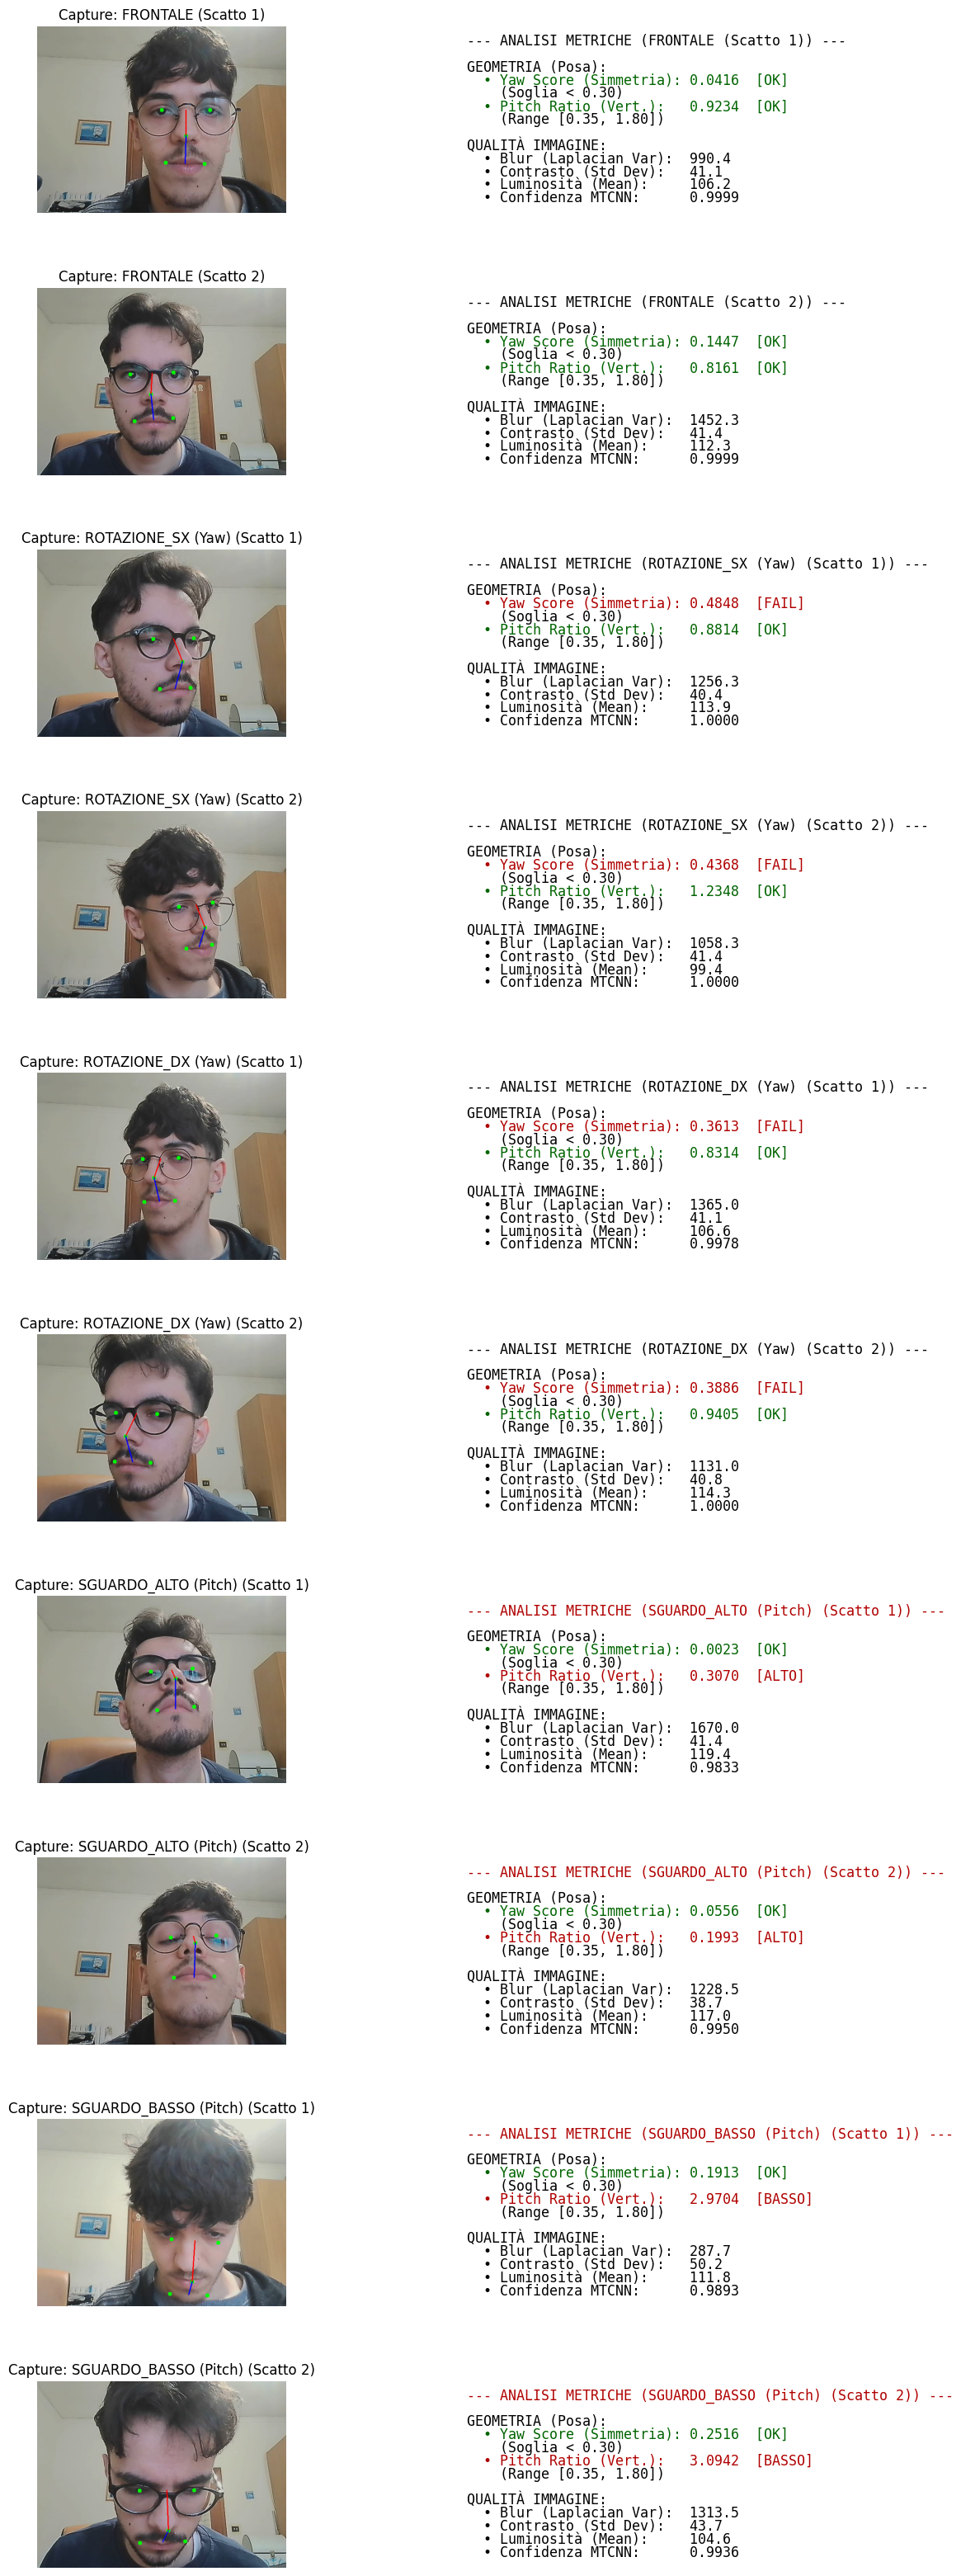

In [ ]:
# Esegui il test chiedendo 2 foto per posa
data_results = run_empirical_test(acquisition, capture_image_colab, samples_per_pose=2)

# Visualizza tutti i 10 risultati
plot_empirical_results(data_results)